## Librerias

In [ ]:
# Graficación
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

# Modelado
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflowjs as tfjs

## Datos

In [2]:
# Descargo dataset de MNIST (Numeros escritos a mano y etiquetados)
datos, metadatos = tfds.load('mnist', as_supervised=True, with_info=True)

# Separo en set de entrenamiento (60k) y test (10k)
datos_train, datos_test = datos['train'], datos['test']

In [3]:
# Función para normalizar los datos (Paso los valores de los pixeles de 0-255 a un intervalo entre 0-1)
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes/= 255 # Aqui el valor minimo queda en 0 y el 255 en 1
    return imagenes, etiquetas

# Aplico la funcion al set de entrenamiento y test
datos_train = datos_train.map(normalizar)
datos_test = datos_test.map(normalizar)

# Utilizo la ram en lugar del disco para almacenar los datasets, asi se entrena mas rapido
datos_train = datos_train.cache()
datos_test = datos_test.cache()

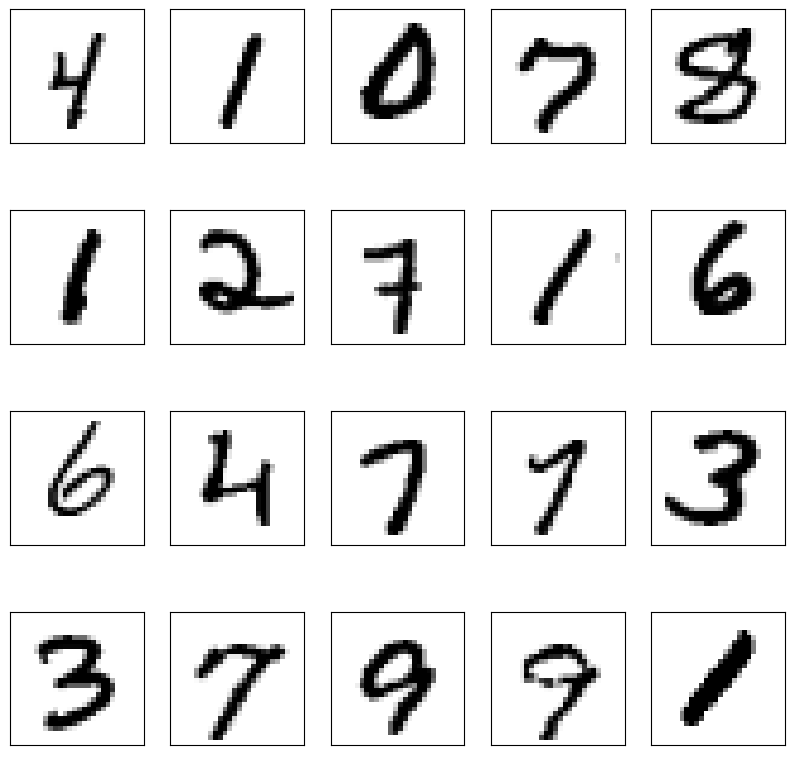

In [4]:
# Visualizo la transformación
# Lista de labels
clases = ['0','1','2','3','4','5','6','7','8','9']

plt.figure(figsize=(10,10))

for i, (imagen, etiqueta) in enumerate(datos_train.take(20)): #Grafico las primeras 20 imagenes
    imagen = imagen.numpy().reshape((28,28))
    plt.subplot(4,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(clases[etiqueta], color='white')

plt.show()

## Modelado

In [5]:
# Crear el modelo con neuronas convolucionales
modelo = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), input_shape=(28,28,1), activation='relu'), #(3,3) es el tamaño de la matriz
    tf.keras.layers.MaxPooling2D(2,2), #(2,2) es el tamaño de la matriz

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2), #(2,2) es el tamaño de la matriz

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

#Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [6]:
#Los numeros de datos de entrenamiento y pruebas (60k y 10k)
num_datos_train = metadatos.splits["train"].num_examples
num_datos_test = metadatos.splits["test"].num_examples

#Trabajar por lotes
TAMANO_LOTE=32

#Shuffle y repeat hacen que los datos esten mezclados de manera aleatoria
#para que el entrenamiento no se aprenda las cosas en orden
datos_train = datos_train.repeat().shuffle(num_datos_train).batch(TAMANO_LOTE)
datos_test = datos_test.batch(TAMANO_LOTE)

In [7]:
#Realizar el entrenamiento

historial = modelo.fit(
    datos_train,
    epochs=60,
    steps_per_epoch=math.ceil(num_datos_train/TAMANO_LOTE)
)

Epoch 1/60
1875/1875 [==============================] - 13s 6ms/step - loss: 0.1279 - accuracy: 0.9619
Epoch 2/60
1875/1875 [==============================] - 10s 6ms/step - loss: 0.0420 - accuracy: 0.9869
Epoch 3/60
1875/1875 [==============================] - 10s 6ms/step - loss: 0.0295 - accuracy: 0.9905
Epoch 4/60
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0215 - accuracy: 0.9932
Epoch 5/60
1875/1875 [==============================] - 10s 6ms/step - loss: 0.0153 - accuracy: 0.9951
Epoch 6/60
1875/1875 [==============================] - 10s 6ms/step - loss: 0.0128 - accuracy: 0.9959
Epoch 7/60
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0107 - accuracy: 0.9966
Epoch 8/60
1875/1875 [==============================] - 10s 6ms/step - loss: 0.0082 - accuracy: 0.9976
Epoch 9/60
1875/1875 [==============================] - 10s 6ms/step - loss: 0.0070 - accuracy: 0.9975
Epoch 10/60
1875/1875 [==============================] - 10s 6ms/step - l

## Exportación

In [8]:
#Exportar el modelo para utilizar en web
modelo.save('numeros_conv.h5')

#Convertirlo a tensorflow.js
!tensorflowjs_converter --input_format keras numeros_conv.h5 exportacion/modelo_CNN

2023-02-14 18:07:35.150278: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'cudart64_110.dll'; dlerror: cudart64_110.dll not found
2023-02-14 18:07:35.150397: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
